In [1]:
import json
import pandas as pd
import pyarrow as pa
import os

import torch

from transformers import AutoTokenizer, AutoImageProcessor

from PIL import Image

import sys
import os.path as osp
import json
import pickle
import time
import itertools
import skimage.io as io
# import matplotlib.pyplot as plt
# from matplotlib.collections import PatchCollection
# from matplotlib.patches import Polygon, Rectangle
from pprint import pprint
import numpy as np
# from refer import REFER

from tqdm import tqdm
from collections import defaultdict

from renaissance.datasets.base_dataset import BaseDataset
from renaissance.datamodules.datamodule_base import BaseDataModule
from renaissance.datasets.refcoco_dataset import RefcocoDataset
from renaissance.datamodules.refcoco_datamodule import RefcocoDataModule

In [2]:
config = {  
    "exp_name":"finetune_ref",
    "seed" : 0,
    # "datasets" : ["coco", "vg", "sbu", "gcc"],
    # "datasets" : ["coco", "vg"],
    "datasets" : ["coco"],
    "loss_names" :{'itm': 0,
    'mlm': 0,
    'mpp': 0,
    'vqa': 0,
    'vcr': 0,
    'vcr_qar': 0,
    'nlvr2': 0,
    'irtr': 0,
    'contras': 0,
    'snli': 0,
    'ref': 1,
    "mrpc" : 0,
    "rte" : 0,
    'wnli' : 0,
    'sst2' : 0,
    'qqp' : 0,
    'qnli' : 0,
    'mnli' : 0,
    'cola' : 0,
    'cifar10' : 0
    },
    "batch_size" : 10,  # this is a desired batch size; pl trainer will accumulate gradients when per step batch is smaller.

    # Image setting
    "train_transform_keys" : ["imagenet"],
    "val_transform_keys" : ["imagenet"],
    "image_size" : 224,
    "patch_size" : 16,
    "draw_false_image" : 1,
    "image_only" : False,
    "resolution_before" : 224,

    # Text Setting
    "vqav2_label_size" : 3129,
    "max_text_len" : 40,
    "text_encoder" : "google/electra-small-discriminator",
    "vocab_size" : 30522,
    "whole_word_masking" : False, # note that whole_word_masking does not work for RoBERTa
    "mlm_prob" : 0.15,
    "draw_false_text" : 0,

    # Transformer Setting
    "num_cross_layers" : 6,
    "image_encoder_hidden_size" : 192,
    "text_encoder_hidden_size" : 256,
    "image_encoder" : "facebook/deit-tiny-patch16-224",
    "cross_layer_hidden_size" : 256,
    "num_cross_layer_heads" : 4,
    "num_layers" : 6,
    "cross_layer_mlp_ratio" : 4,
    "cross_layer_drop_rate" : 0.1,

    # Optimizer Setting
    "optim_type" : "adamw",
    "learning_rate" : 1e-5,
    "weight_decay" : 0.01,
    "decay_power" : 1,
    "max_epoch" : 3,
    "max_steps" : 100000,
    "warmup_steps" : 10000,
    "end_lr" : 0,
    "lr_mult_head" : 5,  # multiply lr for downstream heads
    "lr_mult_cross_modal" : 5,  # multiply lr for the cross-modal module

    # Downstream Setting
    "get_recall_metric" : False,
    
    'freeze_image_encoder' : False,
    'freeze_text_encoder' : False,
    'random_init_text_encoder' : False,
    'random_init_vision_encoder' : False,
    'freeze_cross_modal_layers' : False,
    "model_type" : "METER",

    # PL Trainer Setting
    "resume_from" : None,
    "fast_dev_run" : False,
    "val_check_interval" : 1.0,
    "test_only" : False,

    # "data_root" : data_root,
    "data_root" : "data/arrow",
    "log_dir" : "result",
    "per_gpu_batchsize" : 3,  # you should define this manually with per_gpu_batch_size:#
    "num_gpus" : 1,
    "num_nodes" : 1,
    "load_path" : "",
    "num_workers" : 12,
    "precision" : 16
}

In [3]:
dm = RefcocoDataModule(config)
dm.setup('train')
dm.prepare_data()
dl = dm.train_dataloader()
batch = next(iter(dl))
batch

([{'image': [tensor([[[[-0.8902, -0.8902, -0.8902,  ..., -0.9843, -1.0000, -1.0000],
              [-0.8667, -0.8667, -0.8745,  ..., -0.9765, -0.9765, -0.9765],
              [-0.8745, -0.8745, -0.8745,  ..., -0.9922, -0.9922, -0.9922],
              ...,
              [-0.4745, -0.4902, -0.6000,  ...,  0.3569,  0.4275,  0.4353],
              [-0.4824, -0.4902, -0.5922,  ...,  0.7098,  0.7098,  0.7098],
              [-0.4745, -0.4824, -0.5686,  ...,  0.4039,  0.3647,  0.3569]],
    
             [[-0.8980, -0.8980, -0.8980,  ..., -0.9765, -0.9843, -0.9843],
              [-0.8667, -0.8667, -0.8745,  ..., -0.9765, -0.9765, -0.9765],
              [-0.8745, -0.8745, -0.8745,  ..., -0.9922, -1.0000, -1.0000],
              ...,
              [-0.2078, -0.2314, -0.4039,  ...,  0.5373,  0.6157,  0.6157],
              [-0.2235, -0.2392, -0.4039,  ...,  0.7725,  0.7333,  0.7333],
              [-0.2157, -0.2314, -0.3804,  ...,  0.3255,  0.2235,  0.2157]],
    
             [[-0.9373, -0.93

### Dataset and Properties

In [4]:
ds = dl.dataset
ds 

In [5]:
ds.split

'train'

In [120]:
ds.index_mapper[84073]

(29549, 1)

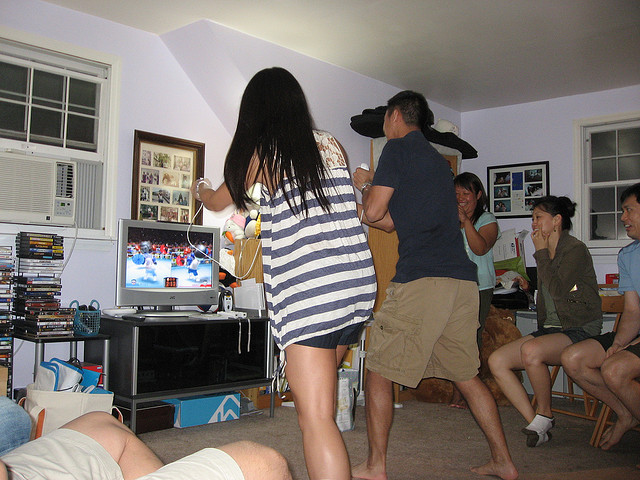

In [121]:
ds.get_raw_image(84073)

In [8]:
ds.table['labels'].__len__()

42404

In [9]:
ds.table['labels'][42079]

<pyarrow.Int64Scalar: 1>

In [10]:
ds.table["labels"][27886]

<pyarrow.Int64Scalar: 1>

In [11]:
ds.table["labels"][-1] #.__len__()

<pyarrow.Int64Scalar: 0>

In [12]:
ds.split

'train'

In [13]:
list(ds.index_mapper.keys())[-1]

120623

In [14]:
ds.index_mapper[113370]

(39858, 1)

In [15]:
ds.table.column_names

['image', 'sentences', 'bboxes', 'labels']

In [16]:
print(len(ds.table))
ds.table.num_rows

42404


42404

In [17]:
df = ds.table.to_pandas()
df.iloc[27886]

image        b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01...
sentences    [middle of photo horse head only, head of hors...
bboxes       [[3.83, 1.09, 223.98, 440.3], [283.93, 118.56,...
labels                                                       1
Name: 27886, dtype: object

In [18]:
list(ds.index_mapper.keys())[-1]

120623

In [19]:
ds.index_mapper[120623]

(42403, 1)

In [20]:
ds.table['labels'][42402]

<pyarrow.Int64Scalar: 1>

In [21]:
120624

120624

In [22]:
data_dir = "data/arrow"
image_only=False
tokenizer = AutoTokenizer.from_pretrained(config["text_encoder"])
processor = AutoImageProcessor.from_pretrained(config['image_encoder'])

In [23]:
train_dataset = RefcocoDataset(
            data_dir =data_dir,
            transform_keys =["imagenet"],
            split="train",
            image_size=32,
            max_text_len=40,
            draw_false_image=False,
            draw_false_text=False,
            image_only=False,
            tokenizer=tokenizer,
            processor="facebook/deit-tiny-patch16-224",
            hf_dataset_key = '',
            task = ''
)

In [24]:
len(train_dataset)

120624

In [25]:
val_dataset = RefcocoDataset(
            data_dir =data_dir,
            transform_keys =["imagenet"],
            split="val",
            image_size=32,
            max_text_len=40,
            draw_false_image=False,
            draw_false_text=False,
            image_only=False,
            tokenizer=tokenizer,
            processor="facebook/deit-tiny-patch16-224",
            hf_dataset_key = '',
            task = ''
)

In [26]:
len(val_dataset)

10834

In [27]:
test_dataset = RefcocoDataset(
            data_dir =data_dir,
            transform_keys =["imagenet"],
            split="test",
            image_size=32,
            max_text_len=40,
            draw_false_image=False,
            draw_false_text=False,
            image_only=False,
            tokenizer=tokenizer,
            processor="facebook/deit-tiny-patch16-224",
            hf_dataset_key = '',
            task = ''
)

In [28]:
len(test_dataset)

10752

### Prototype Init from BaseDataset

In [29]:
import random
import torch
import io
import pyarrow as pa
import os

In [64]:
names = ['refcoco_unc_train']
text_column_name="sentences"
remove_duplicate=False

In [110]:
index = 0
max_bb = 20
image_index, ref_index = ds.index_mapper[index]
# print("Index: ", index)
# print("Image Index: ", image_index)
# print("Ref Index: ", ref_index)
# try:
label = ds.table["labels"][image_index].as_py()
image = np.array(ds.get_raw_image(index))
bboxes = ds.table['bboxes'][image_index].as_py()
# except IndexError:
#     print("Hello World")
#     print("Index: ", index)
#     print("Image Index: ", image_index)
#     print("Ref Index: ", ref_index)
#     return_dict = {
#         # 'ann_id' : ann_id,
#         'image' : [torch.zeros(max_bb,3,ds.image_size,ds.image_size)],#.to(ds.device)],
#         # 'obj_ids' : torch.tensor(obj_ids_total),#.to(ds.device),
#         'target' : 0,#.to(ds.device),
#         'text' : '',
#         'text_ids' : torch.zeros(max_bb,ds.max_text_len,dtype=torch.int8),#.to(ds.device),
#         'text_labels' : torch.zeros(max_bb,ds.max_text_len,dtype=torch.int8),#.to(ds.device),
#         'text_masks' : torch.zeros(max_bb,ds.max_text_len,dtype=torch.int8),#.to(ds.device)
#     }

if len(bboxes) > max_bb:
    truth = bboxes.pop(label)
    bboxes = random.choices(bboxes, k=max_bb-1)
    bboxes.append(truth)
    random.shuffle(bboxes)
    label = bboxes.index(truth)
    
    
sub_images = []
# print("Hello World")
for bbox in bboxes:
    bbox = [int(b) for b in bbox]
    sub = image[bbox[1]:bbox[1]+bbox[3],bbox[0]:bbox[0]+bbox[2]]
    if sub is not None:
        sub = ds.processor(
            sub, 
            return_tensors='pt',
            size={'height':ds.image_size, 'width':ds.image_size}
        )['pixel_values'][0]
        sub_images.append(sub.unsqueeze(0))
num_sub_images = len(sub_images)
num_pad = max_bb - num_sub_images 

pad_image = torch.zeros(1,3,ds.image_size,ds.image_size)
for _ in range(max_bb - num_sub_images):
    sub_images.append(pad_image)

# text ids
text = ds.get_text(index)
text_tokenized = text['text'][1]
ids = torch.tensor(text_tokenized['input_ids'])
repeat_ids = ids.repeat(num_sub_images,1)
pad_ids =  torch.zeros(num_pad,ds.max_text_len,dtype=torch.int8)
text_ids = torch.cat((repeat_ids, pad_ids))#.to(torch.long)
# text masks
masks = torch.tensor(text_tokenized['attention_mask'])
repeat_masks = masks.repeat(num_sub_images,1)
pad_masks = torch.zeros(num_pad, ds.max_text_len, dtype=torch.int8)
text_masks = torch.cat((repeat_masks, pad_masks))#.to(torch.long)
# text_labels
labels = torch.full((ds.max_text_len,),-100, dtype=torch.int8)
repeat_labels = labels.repeat(num_sub_images, 1)
pad_labels = torch.zeros(num_pad, ds.max_text_len, dtype=torch.int8)
text_labels = torch.cat((repeat_labels, pad_labels))#.to(torch.long)

# target = ds.table

return_dict = {
    # 'ann_id' : ann_id,
    'image' : [torch.cat(sub_images)],#.to(ds.device)],
    # 'obj_ids' : torch.tensor(obj_ids_total),#.to(ds.device),
    'target' : label,#.to(ds.device),
    'text' : text['text'][0],
    'text_ids' : text_ids,#.to(ds.device),
    'text_labels' : text_labels,#.to(ds.device),
    'text_masks' : text_masks,#.to(ds.device)
}
return_dict

{'image': [tensor([[[[-0.4980, -0.4353, -0.3412,  ..., -0.6627, -0.6157, -0.5843],
            [-0.4980, -0.4353, -0.3412,  ..., -0.6627, -0.6157, -0.5843],
            [-0.5294, -0.4431, -0.3255,  ..., -0.6549, -0.6157, -0.5843],
            ...,
            [-0.7020, -0.7412, -0.7961,  ..., -0.0353, -0.0118,  0.0039],
            [-0.6863, -0.7333, -0.8039,  ..., -0.0275,  0.0118,  0.0353],
            [-0.6863, -0.7333, -0.8039,  ..., -0.0275,  0.0118,  0.0353]],
  
           [[-0.0824, -0.0196,  0.0667,  ..., -0.3882, -0.3569, -0.3333],
            [-0.0824, -0.0196,  0.0667,  ..., -0.3882, -0.3569, -0.3333],
            [-0.1373, -0.0510,  0.0745,  ..., -0.3882, -0.3569, -0.3333],
            ...,
            [-0.7020, -0.7255, -0.7725,  ...,  0.2941,  0.3255,  0.3490],
            [-0.6784, -0.7176, -0.7804,  ...,  0.3020,  0.3490,  0.3804],
            [-0.6784, -0.7176, -0.7804,  ...,  0.3020,  0.3490,  0.3804]],
  
           [[-0.8039, -0.7176, -0.5843,  ..., -0.8902, -0.858

In [111]:
label

14

In [114]:
print(len(bboxes))
bboxes

20


[[56.09, 529.28, 134.3, 76.15],
 [209.65, 129.24, 51.08, 41.54],
 [224.36, 548.31, 54.65, 73.35],
 [358.93, 353.37, 11.83, 12.06],
 [345.34, 353.8, 13.79, 10.69],
 [336.85, 359.26, 16.93, 13.82],
 [33.63, 548.4, 30.03, 25.71],
 [346.13, 373.67, 17.24, 12.14],
 [332.4, 371.05, 17.14, 13.81],
 [56.09, 529.28, 134.3, 76.15],
 [216.58, 261.7, 81.64, 211.89],
 [332.4, 371.05, 17.14, 13.81],
 [363.79, 371.19, 14.6, 14.6],
 [372.81, 363.25, 11.47, 11.47],
 [103.93, 299.99, 134.22, 177.42],
 [0.0, 600.19, 38.63, 39.81],
 [163.36, 580.87, 28.0, 22.85],
 [216.58, 261.7, 81.64, 211.89],
 [202.09, 70.54, 57.03, 58.12],
 [224.36, 548.31, 54.65, 73.35]]

In [115]:
return_dict['image'][0].shape

torch.Size([20, 3, 224, 224])

In [116]:
return_dict['text_ids'].shape

torch.Size([20, 40])

In [117]:
return_dict['text_labels'].shape

torch.Size([20, 40])

In [118]:
return_dict['text_masks'].shape

torch.Size([20, 40])

In [119]:
return_dict['target']

14

#### Down Sample Bounding Boxes

In [104]:
truth = bboxes.pop(label)
bboxes = random.choices(bboxes, k=max_bb-1)
bboxes.append(truth)
random.shuffle(bboxes)
label = bboxes.index(truth)
print(label)
bboxes

8


[[202.09, 70.54, 57.03, 58.12],
 [363.79, 371.19, 14.6, 14.6],
 [56.09, 529.28, 134.3, 76.15],
 [11.4, 595.97, 169.39, 44.03],
 [249.13, 67.33, 48.11, 63.18],
 [56.09, 529.28, 134.3, 76.15],
 [372.81, 363.25, 11.47, 11.47],
 [1.0, 164.0, 425.0, 475.0],
 [103.93, 299.99, 134.22, 177.42],
 [115.33, 465.3, 136.17, 78.2],
 [224.36, 548.31, 54.65, 73.35],
 [83.6, 270.27, 85.05, 183.06],
 [83.6, 270.27, 85.05, 183.06],
 [224.36, 548.31, 54.65, 73.35],
 [325.01, 343.61, 25.09, 20.64],
 [363.79, 371.19, 14.6, 14.6],
 [209.65, 129.24, 51.08, 41.54],
 [325.01, 343.61, 25.09, 20.64],
 [353.15, 360.57, 14.67, 13.16],
 [163.36, 580.87, 28.0, 22.85]]